# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,recall_score
from sklearn import tree


# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/MIT Course/Classification and Hypothesis Testing/Project/ExtraaLearn.csv", sep=',')

## Data Overview

- Observations
- Sanity checks

In [4]:
data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [5]:
data.shape

(4612, 15)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

**Observations:**

- There are **4612 observations and 15 columns** in the dataset.
- All the columns have 4612 non-null values, i.e., **there are no missing values in the data.**

In [7]:
data.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


**Observations:**

- We can drop the column - ID as it is unique for each customer and will not add value to the model.
- Most of the variables are categorical except - Age, Website_Visits, time spent online and page views per visit.

In [8]:
# Dropping ID column
data.drop(columns='ID',inplace=True)

In [9]:
#seperating the columns into numerical and categorical
cat_col = ['current_occupation','first_interaction','profile_completed','last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']
num_col = ['age','website_visits','time_spent_on_website','page_views_per_visit']

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


mean age is 46.2, min is 18 and max is 63
on Avg a lead has visited the website 3 times


In [49]:
for i in cat_col:
    print(data[i].value_counts())
    print('*'*40)

current_occupation
Professional    2404
Unemployed      1330
Student          496
Name: count, dtype: int64
****************************************
first_interaction
Website       2342
Mobile App    1888
Name: count, dtype: int64
****************************************
profile_completed
High      2091
Medium    2042
Low         97
Name: count, dtype: int64
****************************************
last_activity
Email Activity      2102
Phone Activity      1115
Website Activity    1013
Name: count, dtype: int64
****************************************
print_media_type1
No     3772
Yes     458
Name: count, dtype: int64
****************************************
print_media_type2
No     4014
Yes     216
Name: count, dtype: int64
****************************************
digital_media
No     3753
Yes     477
Name: count, dtype: int64
****************************************
educational_channels
No     3594
Yes     636
Name: count, dtype: int64
****************************************
referra

## **Observations**

* current_occupation: The majority of users are professionals (2404), followed by unemployed individuals (1330) and students (496).
* first_interaction: Most users first interacted via the website (2342), with fewer coming through the mobile app (1888).
* profile_completed: A large portion of users have either high (2091) or medium (2042) profile completion, with very few having low completion (97).
* last_activity: Most users' last recorded activity was via email (2102), followed by phone (1115) and website (1013) interactions.
* print_media_type1: Only a small portion of users (458) engaged with print media type 1, while the vast majority (3772) did not.
* print_media_type2: Similarly, very few users (216) were reached through print media type 2 compared to those who weren’t (4014).
* digital_media: Engagement through digital media is limited (477) compared to non-digital media users (3753).
* educational_channels: Educational channels reached 636 users, while most (3594) were not engaged through these channels.
* referral: Referrals are rare, with only 83 users coming through this channel compared to 4147 who did not.
* status: About 30% of users converted (status = 1, 1275), while the majority did not (status = 0, 2955).

In [13]:
def histogram_boxplot(data, feature, figsize = (15, 5), kde = False, bins = None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 1, # have both graphs on the same row
        ncols = 2, # have 2 graphs per row
        sharex = True,  # X-axis will be shared among all subplots
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "#EC5656"
    )  # Boxplot will be created and a triangle will indicate the mean value of the column
    ax_box2.set_title(f"Boxplot of {feature}", fontsize=12) #adding title to boxplot

    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # creating histogram
    ax_hist2.set_title(f"Histogram of {feature}", fontsize=12) #setting the title

    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

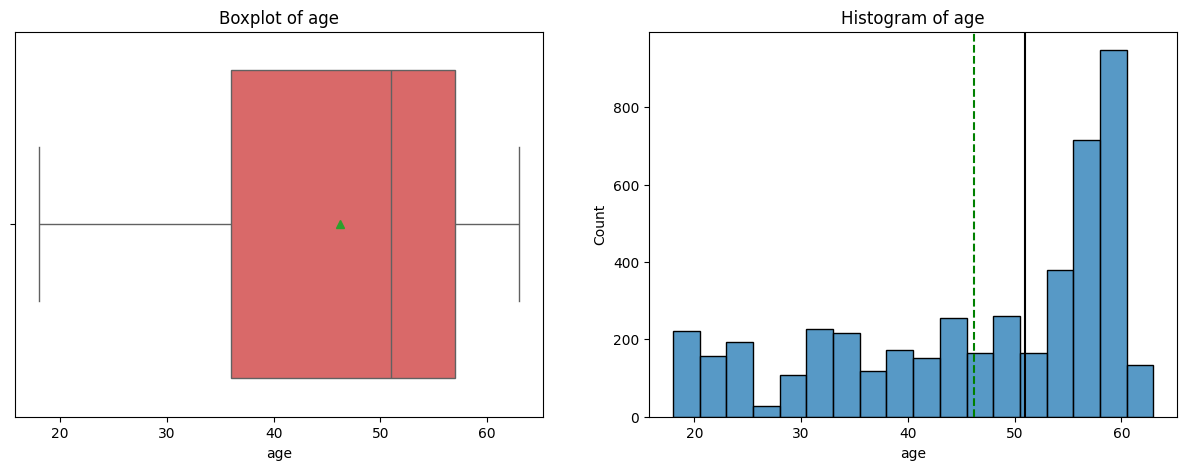

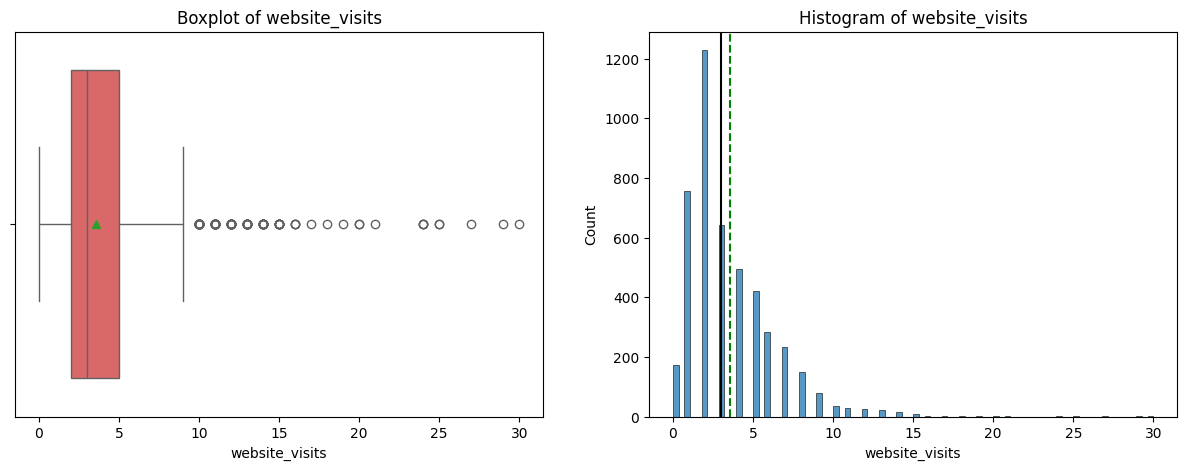

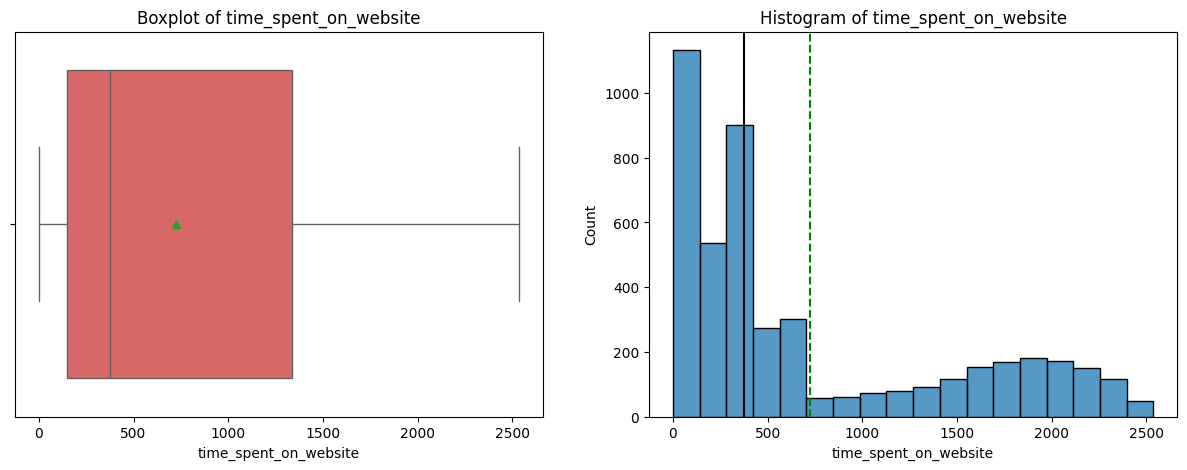

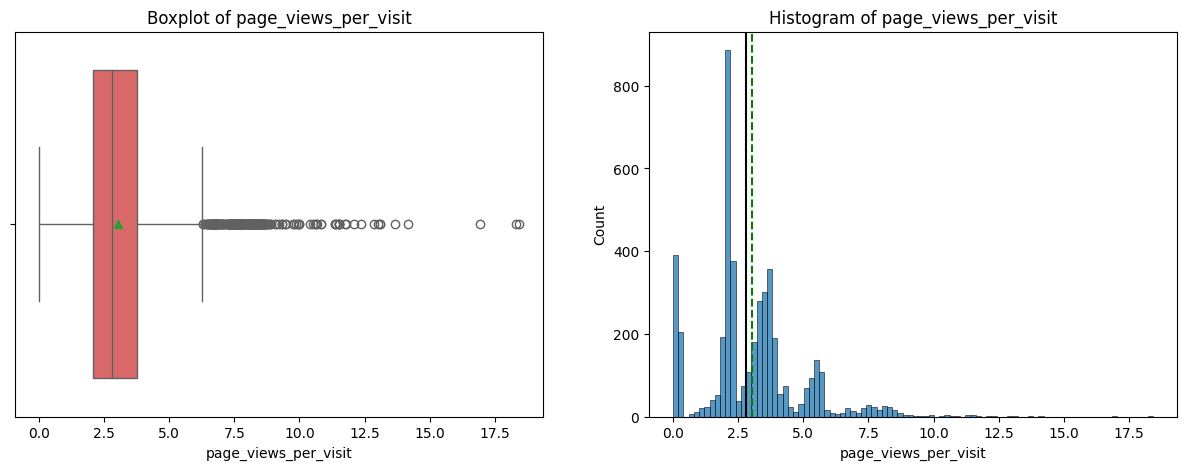

In [14]:
for col in num_col:
    histogram_boxplot(data, col)

###**Observations**:
* Age is left skewed, the median is around 46 with the majority of people in
their late 55-60s.
* Website Visits is right skewed, with many outliers after 10, we will need ot further look into this.
* Time spent on the website is right-skewed, with a mean of around 700 seconds. However, the majority of users spend 0 seconds on the site, indicating that many visitors likely drop off at the home page without engaging further.
* Page views per visit are right-skewed with many outliers, and the mean sits at approximately 2.6.This indicates that while most users view only a few pages per visit but a smaller number of highly engaged users are viewing significantly more, pulling the average upward. These outliers suggest there is a subset of visitors finding the content highly engaging or navigating deeper into the site.

In [15]:
data[data['website_visits']>10]

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
6,56,Professional,Mobile App,Medium,13,625,2.015,Website Activity,No,No,Yes,No,No,1
31,55,Unemployed,Website,Medium,13,1055,1.373,Email Activity,No,No,Yes,Yes,No,1
32,58,Professional,Mobile App,High,12,1151,18.434,Phone Activity,No,No,No,Yes,No,0
66,59,Unemployed,Mobile App,Medium,25,311,2.184,Phone Activity,No,No,Yes,No,No,0
201,57,Professional,Mobile App,High,14,66,2.043,Email Activity,No,No,No,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4566,59,Unemployed,Mobile App,High,13,30,3.200,Website Activity,No,No,No,Yes,No,0
4571,54,Professional,Website,High,12,1513,5.703,Email Activity,No,No,No,No,No,1
4583,49,Professional,Website,Medium,24,1039,2.064,Email Activity,Yes,No,No,No,No,1
4589,21,Student,Website,High,16,251,2.108,Phone Activity,No,No,No,No,No,0


In [16]:
data[data['page_views_per_visit']>6]

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
32,58,Professional,Mobile App,High,12,1151,18.434,Phone Activity,No,No,No,Yes,No,0
47,35,Professional,Mobile App,Medium,2,497,7.050,Email Activity,No,No,No,No,No,0
110,31,Professional,Website,High,1,187,7.364,Email Activity,No,No,No,Yes,No,1
121,56,Professional,Mobile App,Medium,2,561,6.887,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4481,48,Professional,Mobile App,Medium,2,881,6.165,Email Activity,No,No,No,Yes,No,0
4507,33,Professional,Mobile App,High,5,83,6.822,Email Activity,No,No,No,No,No,0
4514,42,Professional,Mobile App,Medium,2,762,7.997,Phone Activity,No,No,No,No,No,0
4572,55,Unemployed,Mobile App,High,1,617,7.397,Phone Activity,No,No,No,No,No,0


In [17]:
data.drop(index=data[data['website_visits']>10].index,inplace=True)

In [18]:
data.drop(index=data[data['page_views_per_visit']>6].index,inplace=True)

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [19]:
for column in cat_col:
    data[column]=data[column].astype('category')

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4230 entries, 0 to 4611
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    4230 non-null   int64   
 1   current_occupation     4230 non-null   category
 2   first_interaction      4230 non-null   category
 3   profile_completed      4230 non-null   category
 4   website_visits         4230 non-null   int64   
 5   time_spent_on_website  4230 non-null   int64   
 6   page_views_per_visit   4230 non-null   float64 
 7   last_activity          4230 non-null   category
 8   print_media_type1      4230 non-null   category
 9   print_media_type2      4230 non-null   category
 10  digital_media          4230 non-null   category
 11  educational_channels   4230 non-null   category
 12  referral               4230 non-null   category
 13  status                 4230 non-null   category
dtypes: category(10), float64(1), int64(3)
memory 

In [21]:
df = data.copy()

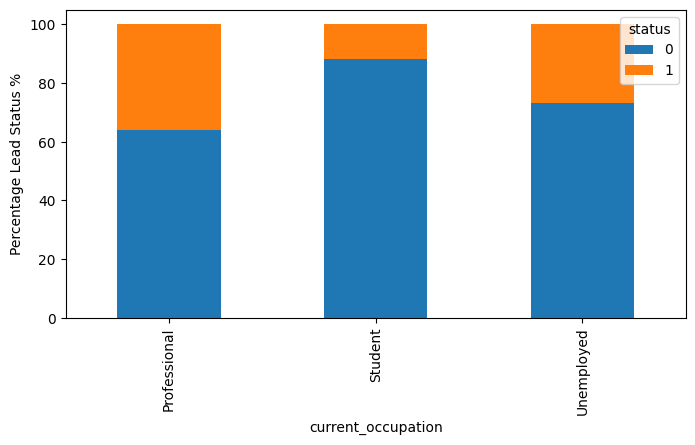

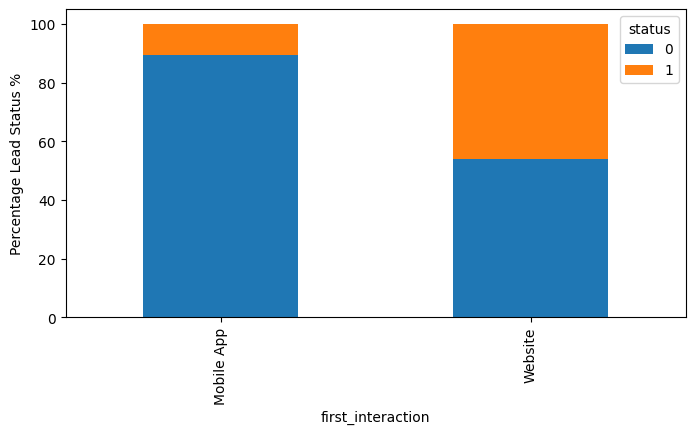

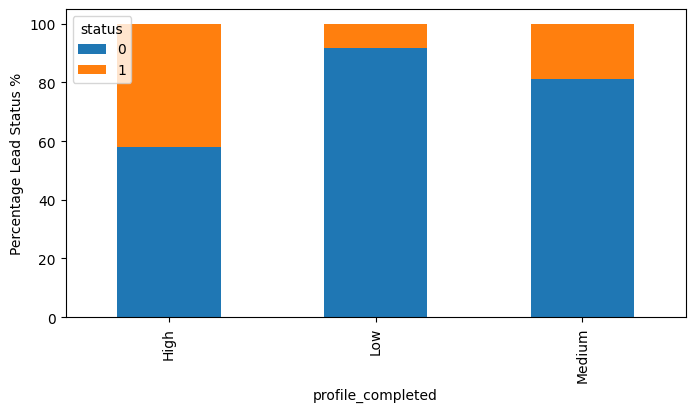

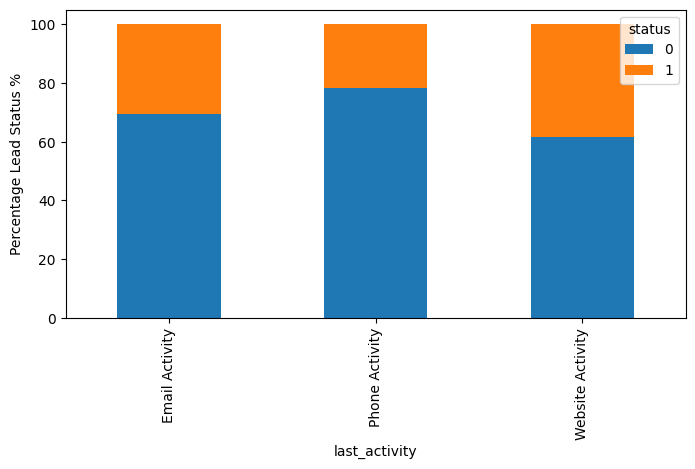

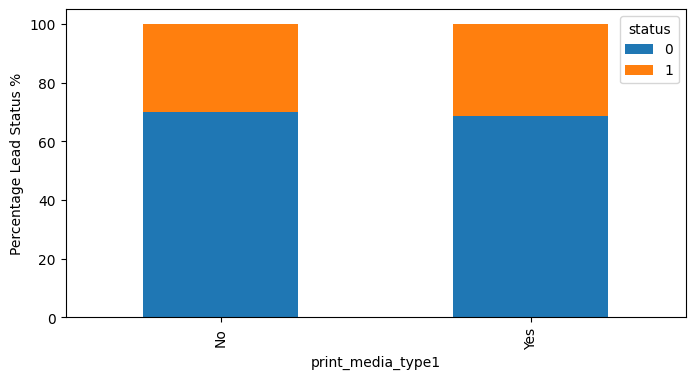

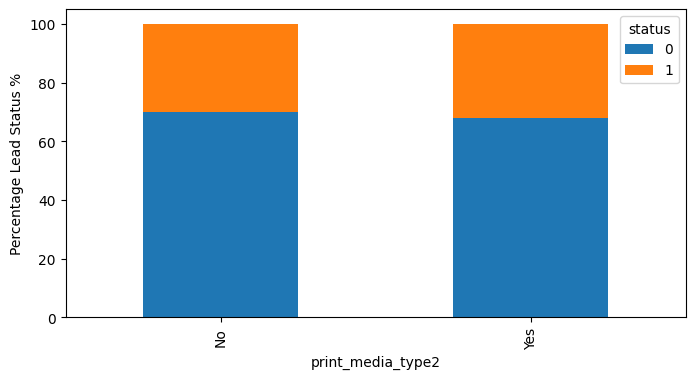

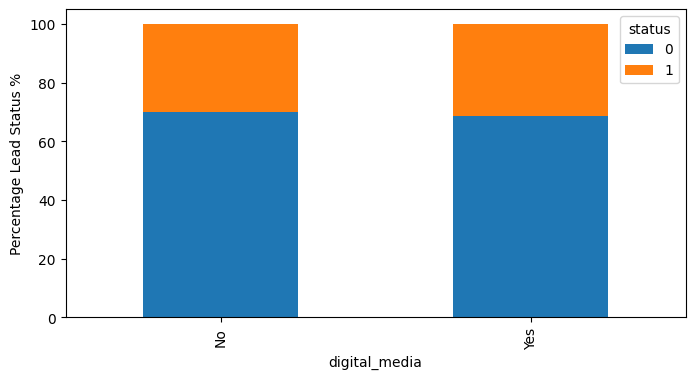

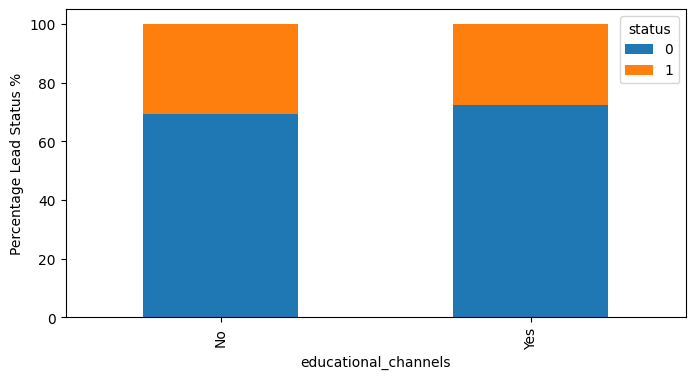

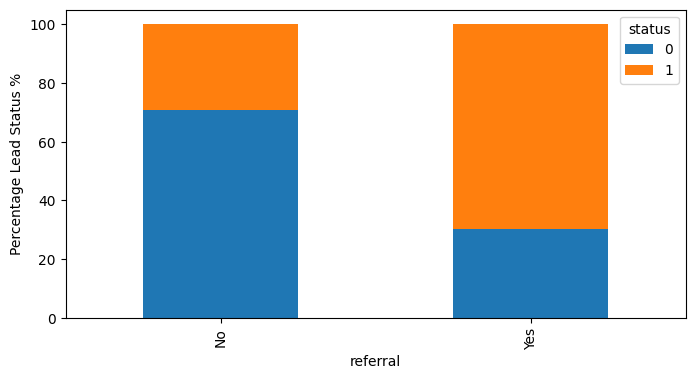

In [22]:
for i in cat_col:
    if i!='status':
        (pd.crosstab(df[i],df['status'],normalize='index')*100).plot(kind='bar',figsize=(8,4),stacked=True)
        plt.ylabel('Percentage Lead Status %')

###**Questions**

1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.

  *   Profesional People have a 35% chance of participating in the program, followed by unemployed with a 25%. Students do not tend to participate with only 10% participation

2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
  * Yes when a lead uses the website they have a 45% chance of participating in comparison to Mobile at only 10%

3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
  * Educational Channels far out play any other form of interaction with a nearly 80% chance of these leads participating in the program.

4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
  * The highest lead conversion rate comes from referrals, with a conversion rate of approximately 70%.This makes intuitive sense, as referral leads typically come with a higher level of trust and intent, making them more likely to convert compared to leads from less personal sources like print or digital media.

5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?
 * Yes, having more detailed information in a prospect's profile correlates with a higher likelihood of conversion.In fact, users with more complete profiles show a conversion rate of around 40%, suggesting that individuals who share more personal data are more engaged and likely to participate in the program.

In [23]:
df.groupby(['status'])[num_col].mean()

,age,website_visits,time_spent_on_website,page_views_per_visit
status,,,,
0,45.281218,3.29780,571.281218,2.685522
1,48.727059,3.25098,1062.425882,2.753629


## **Observations**

* Age: Converted users tend to be older on average (48.7 years) compared to non-converted users (45.3 years).

* Website Visits: Both groups have a similar number of visits, though non-converted users have a slightly higher average (3.30 vs. 3.25).

* Time Spent on Website: Converted users spend significantly more time on the website (1062s) compared to non-converted users (571s).

* Page Views per Visit: Converted users view slightly more pages per visit (2.75) than non-converted users (2.69), suggesting deeper engagement.

<Axes: >

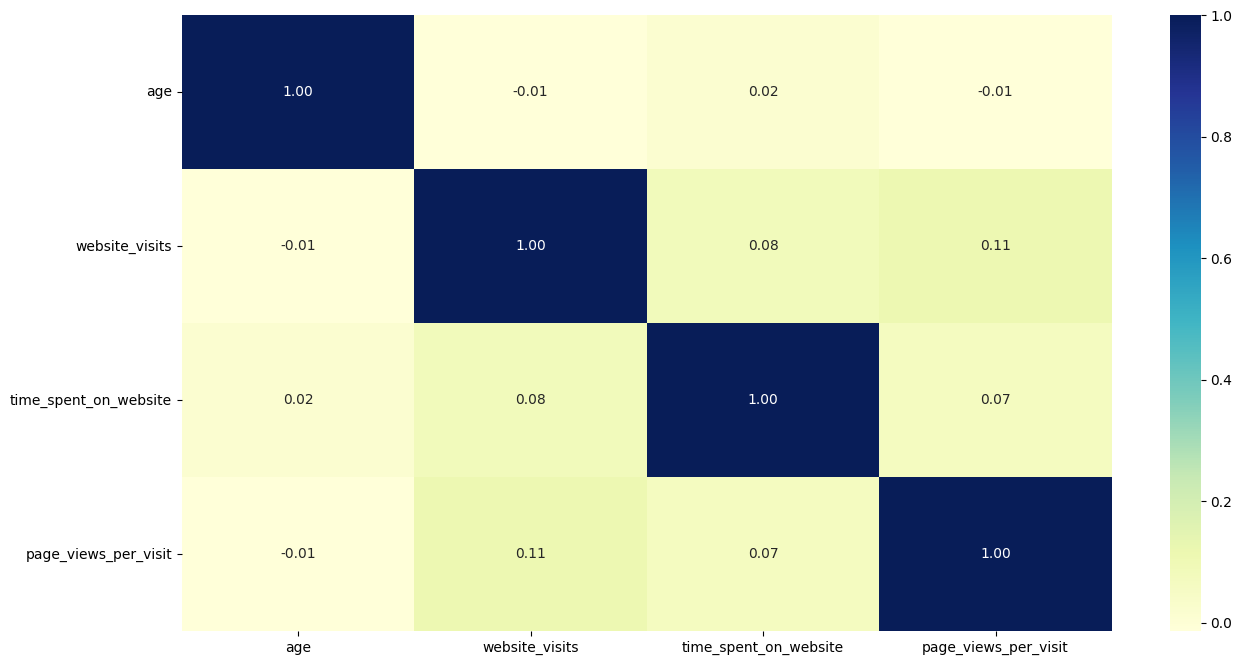

In [24]:
# Plotting the correlation between numerical variables
plt.figure(figsize=(15,8))
sns.heatmap(df[num_col].corr(),annot=True, fmt='0.2f', cmap='YlGnBu')

## **Observations**
*  There is little to no correlation between the numerical variables and conversion status, indicating that these individual features alone may not be strong predictors of user conversion.




## EDA

- It is a good idea to explore the data once again after manipulating it.

In [25]:
df.shape

(4230, 14)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4230 entries, 0 to 4611
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    4230 non-null   int64   
 1   current_occupation     4230 non-null   category
 2   first_interaction      4230 non-null   category
 3   profile_completed      4230 non-null   category
 4   website_visits         4230 non-null   int64   
 5   time_spent_on_website  4230 non-null   int64   
 6   page_views_per_visit   4230 non-null   float64 
 7   last_activity          4230 non-null   category
 8   print_media_type1      4230 non-null   category
 9   print_media_type2      4230 non-null   category
 10  digital_media          4230 non-null   category
 11  educational_channels   4230 non-null   category
 12  referral               4230 non-null   category
 13  status                 4230 non-null   category
dtypes: category(10), float64(1), int64(3)
memory 

In [27]:
# Creating list of dummy columns
to_get_dummies_for = ['current_occupation', 'first_interaction','profile_completed', 'last_activity','print_media_type1', 'print_media_type2',  'digital_media','educational_channels', 'referral']

# Creating dummy variables
df = pd.get_dummies(data = df, columns = to_get_dummies_for, drop_first = True)

In [28]:
Y= df['status']
X= df.drop(columns = ['status'])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify = Y)

## Building a Decision Tree model

In [30]:
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))

    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Converted', 'Converted'], yticklabels=['Not Converted', 'Converted'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [31]:
#as Status is 0 - 0.701431 and 1  -  0.298569
dt = DecisionTreeClassifier(class_weight = {0: 0.70, 1: 0.30}, random_state = 1)

In [32]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.7, 1: 0.3}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2069
           1       1.00      1.00      1.00       892

    accuracy                           1.00      2961
   macro avg       1.00      1.00      1.00      2961
weighted avg       1.00      1.00      1.00      2961



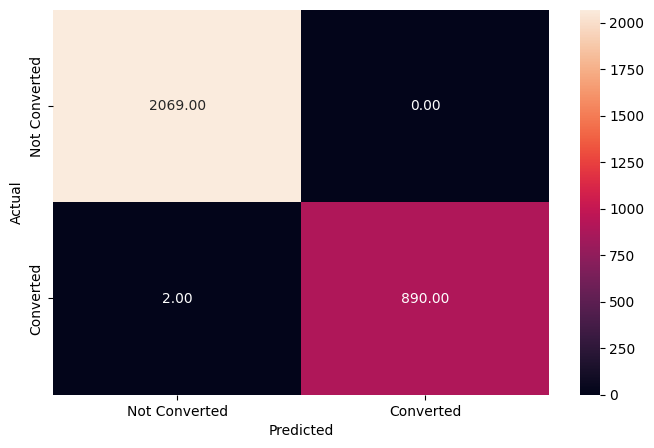

In [33]:
y_train_pred_dt = dt.predict(X_train)

metrics_score(y_train, y_train_pred_dt)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       886
           1       0.71      0.71      0.71       383

    accuracy                           0.83      1269
   macro avg       0.79      0.79      0.79      1269
weighted avg       0.83      0.83      0.83      1269



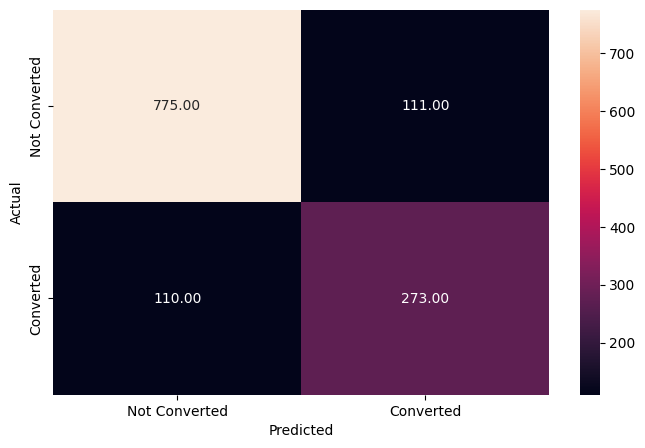

In [34]:
y_test_pred_dt = dt.predict(X_test)

metrics_score(y_test, y_test_pred_dt)

## **Observations**
*  The Decision Tree works well on the training data but not  well on the test data as the recall is 0.87 in comparison to 1 for the training dataset,the decision tree is overfitting the data.
*   1  has lower precision and recall (both at 0.71), suggesting the model is less accurate at identifying true conversions as we are focused on recall due to wanting to convert non-users to users to generate higher revenue.



## Do we need to prune the tree?

In [67]:
# Choose the type of classifier
dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.70, 1: 0.3}, random_state = 1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 10)

# Fitting the grid search on the train data
gridCV = gridCV.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
dtree_estimator = gridCV.best_estimator_

# Fit the best estimator to the data
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.7, 1: 0.3}, max_depth=np.int64(6),
                       min_samples_leaf=5, random_state=1)

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2069
           1       0.85      0.72      0.78       892

    accuracy                           0.88      2961
   macro avg       0.87      0.83      0.84      2961
weighted avg       0.87      0.88      0.87      2961



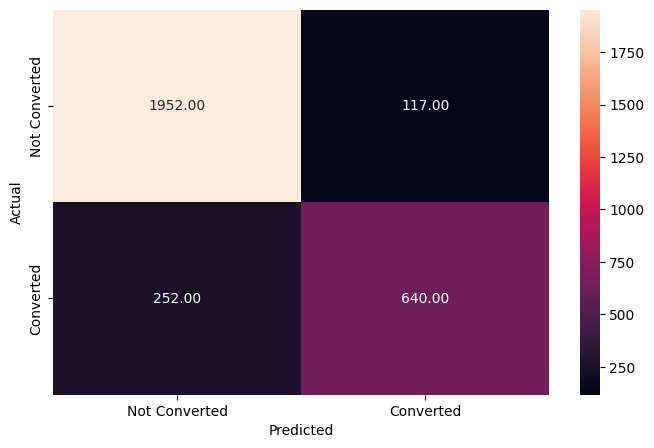

In [68]:
y_train_pred_dt = dtree_estimator.predict(X_train)

metrics_score(y_train, y_train_pred_dt)

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       886
           1       0.81      0.65      0.72       383

    accuracy                           0.85      1269
   macro avg       0.83      0.79      0.81      1269
weighted avg       0.84      0.85      0.84      1269



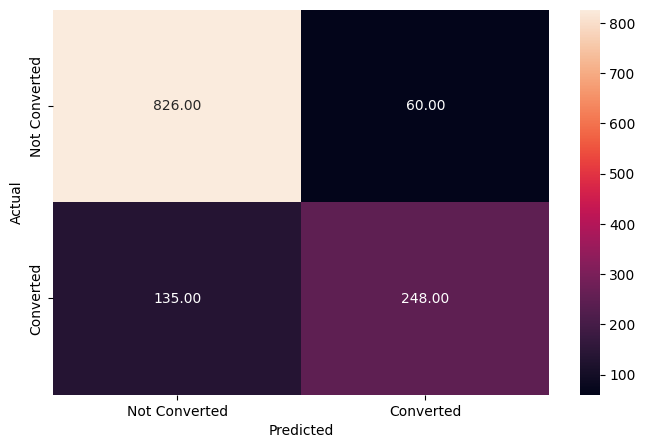

In [69]:
y_test_pred_dt = dtree_estimator.predict(X_test)

metrics_score(y_test, y_test_pred_dt)

##**Observatrions**

*  The tuned model has successfully reduced overfitting; however, recall has decreased while precision has increased.This means the model is now more conservative in predicting leads who convert, making fewer false positive prediction but also missing more actual positives.
* The imbalance in precision/recall for 1 suggests more work is needed to improve distinguishing true converters—possibly with further tuning, feature engineering, or alternative algorithms.

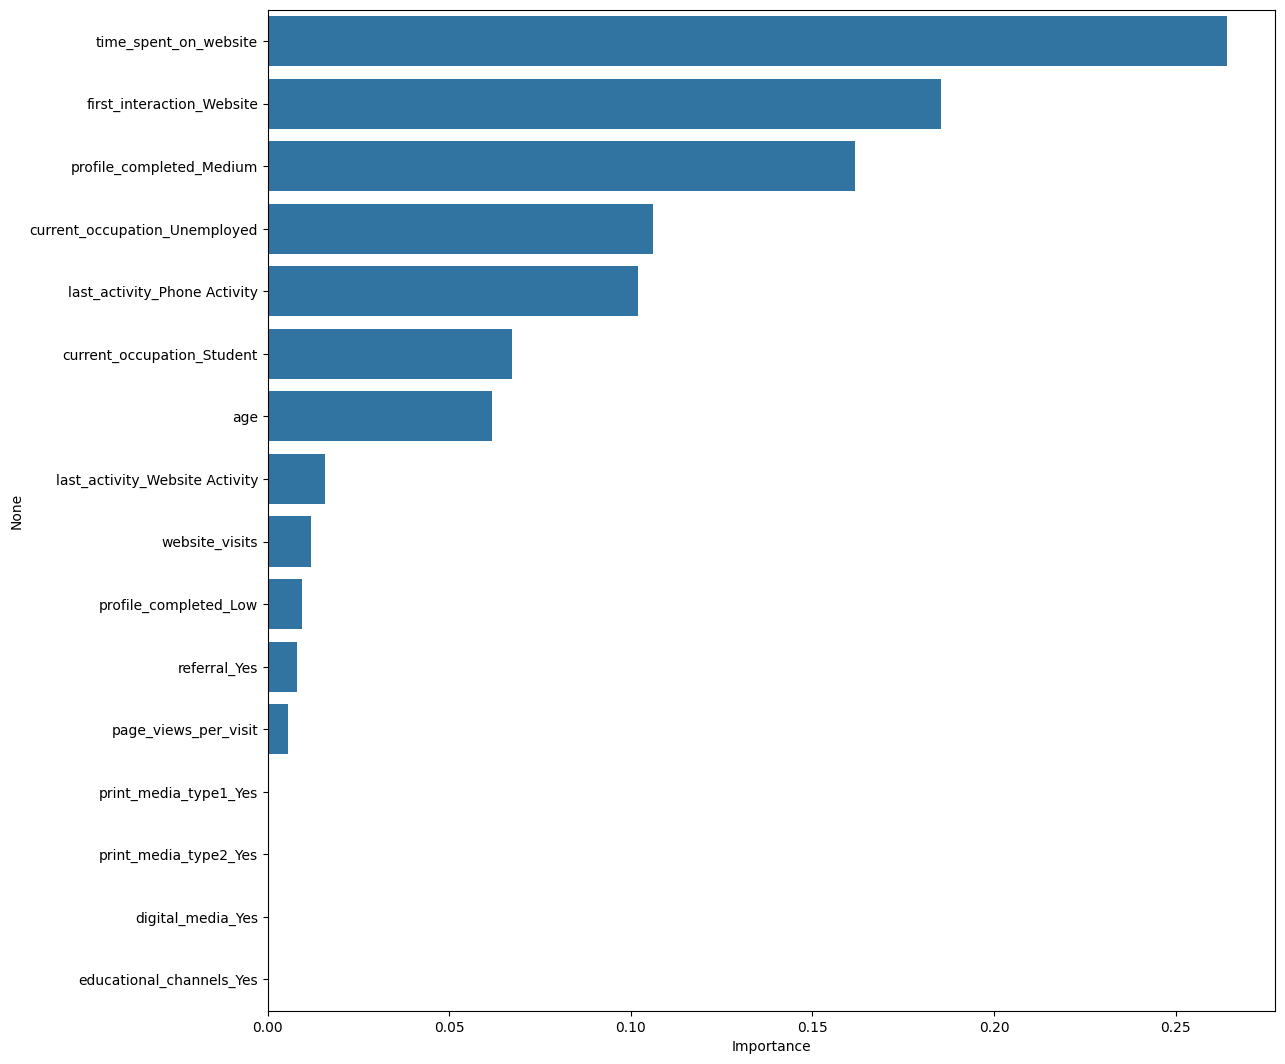

In [70]:
importances = dtree_estimator.feature_importances_
columns = X.columns

importance_df = pd.DataFrame(importances, index=columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(13, 13))
sns.barplot(data=importance_df, x='Importance', y=importance_df.index)
plt.show()

##**Observations**

* According to the model, the most important features are time spent on the website, first interaction channel, having a medium-completed profile, and being unemployed. However, this seems counterintuitive because the highest conversion rates actually come from users with high profile completion and those who are employed.

## Building a Random Forest model

In [39]:
rf_estimator = RandomForestClassifier(class_weight = {0: 0.7, 1: 0.3}, random_state = 1)

rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.7, 1: 0.3}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2069
           1       1.00      1.00      1.00       892

    accuracy                           1.00      2961
   macro avg       1.00      1.00      1.00      2961
weighted avg       1.00      1.00      1.00      2961



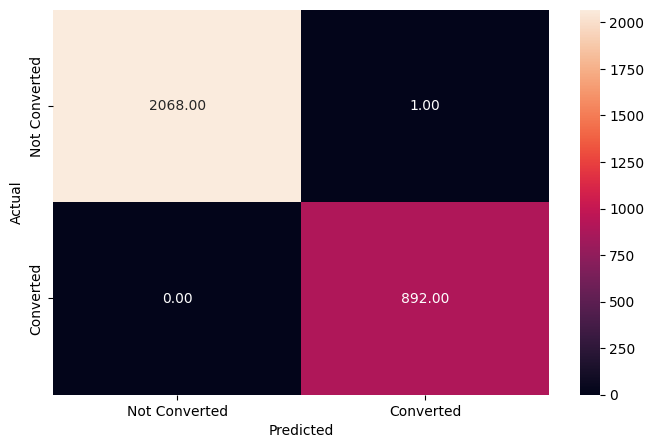

In [40]:
y_pred_train_rf = rf_estimator.predict(X_train)

metrics_score(y_train, y_pred_train_rf)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       886
           1       0.76      0.70      0.73       383

    accuracy                           0.84      1269
   macro avg       0.82      0.80      0.81      1269
weighted avg       0.84      0.84      0.84      1269



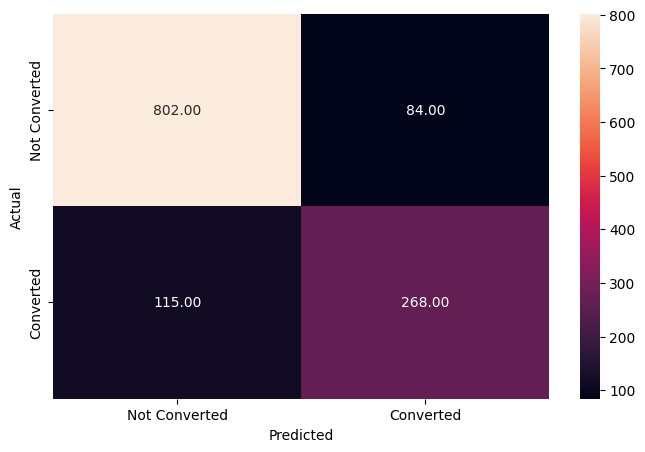

In [41]:
# Checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

#**Observations**
*   Overfitting as recall is  1 on traingng and 70 on test, missing about 30% of actual positives in testing.



## Do we need to prune the tree?

In [71]:
# Choose the type of classifier
rf_estimator_tuned = RandomForestClassifier(class_weight = {0: 0.7, 1: 0.3}, random_state = 1)

# Grid of parameters to choose from
params_rf = {
        "n_estimators": [100, 250, 600],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
}


# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, params_rf, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

In [72]:
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.7, 1: 0.3}, max_features=0.7,
                       min_samples_leaf=np.int64(1), random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2069
           1       1.00      1.00      1.00       892

    accuracy                           1.00      2961
   macro avg       1.00      1.00      1.00      2961
weighted avg       1.00      1.00      1.00      2961



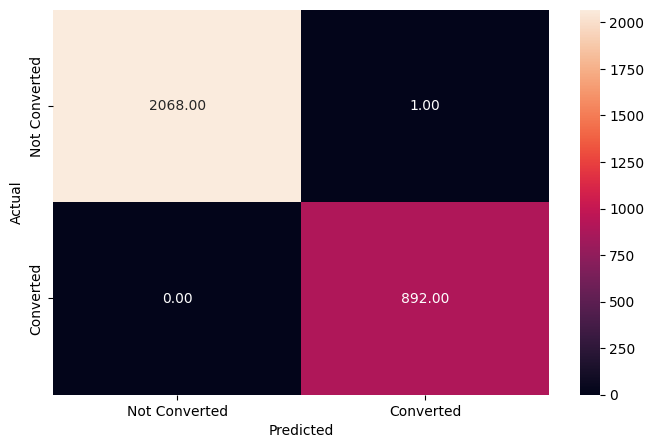

In [73]:
# Checking performance on the training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(X_train)

metrics_score(y_train, y_pred_train_rf_tuned)

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       886
           1       0.76      0.69      0.73       383

    accuracy                           0.84      1269
   macro avg       0.82      0.80      0.81      1269
weighted avg       0.84      0.84      0.84      1269



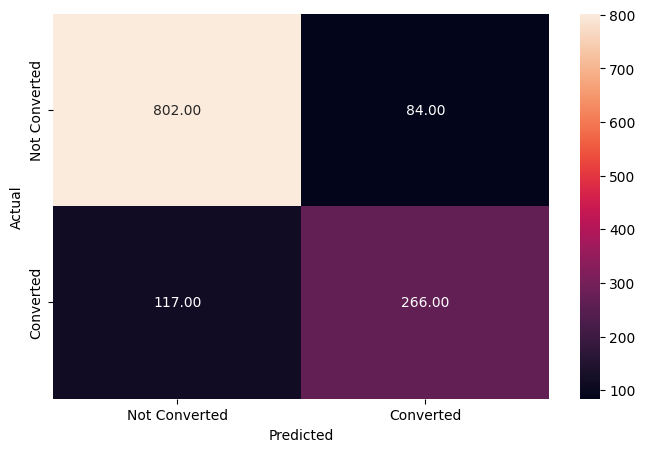

In [74]:
y_pred_test_rf_tuned = rf_estimator_tuned.predict(X_test)

metrics_score(y_test, y_pred_test_rf_tuned)

##**Observations**


* The model shows signs of overfitting on the training data, with a recall of 0.69 on the test set accompanied by a decrease in precision. Overall, this indicates the model isn’t performing optimally—even after hyperparameter tuning, the random forest struggles to balance recall and precision effectively.

<Axes: xlabel='Importance', ylabel='None'>

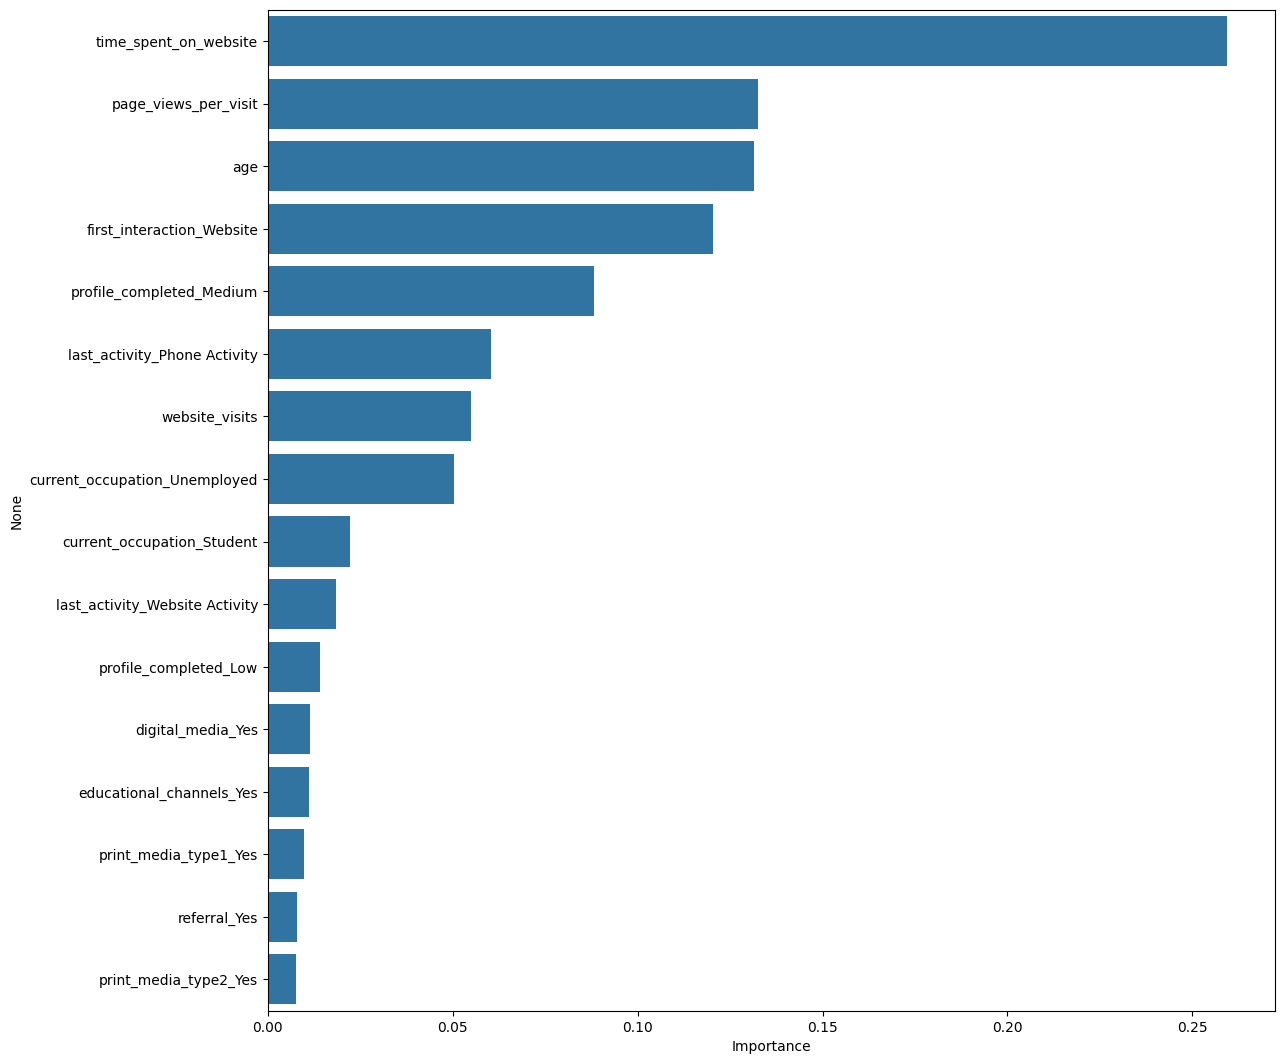

In [48]:
# Plotting feature importance
importances = rf_estimator_tuned.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index)

#**Observations**
* Although the model has slightly lower recall, it provides better feature importance, with the top features aligning more logically with business insights.
* Time spent on the website, page views per visit, age, and first interaction via the website make more sense as important features, aligning well with our earlier analysis.

## **Actionable Insights and Recommendations**

Recommendations for Leads:
*  Focus on Referral and High-Quality Leads:
Since referrals have the highest conversion rate (~70%), prioritize and incentivize referral programs to boost lead quality and conversions.

* Enhance Website Engagement:
Time spent on the website and page views per visit are strong predictors. Improve website content, navigation, and user experience to keep visitors engaged longer and encourage deeper exploration. Especially focus on the landing page as to increase the intial time spent on the website.

* Improve Profile Completion Rates:
Users with high or medium profile completion convert better. Implement strategies (like progressive profiling or incentives) to encourage users to provide more complete information

* Target Age-Specific Marketing:
Older users show slightly higher conversion rates. Tailor marketing messages and offers to appeal to different age segments for more personalized engagement.

Recommendations on the data:
* Balance Precision and Recall:
Since recall is important for capturing more potential converters, consider tesing other models to see if we can capture better recall and precision.
* Address Overfitting in Models:
Look further into why both models are overfitting.

